<a href="https://colab.research.google.com/github/francji1/01ZLMA/blob/main/code/01ZLMA_ex08_Binary_Data_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01ZLMA - Exercise 08

Exercise 08 of the course [01ZLMA](https://math.fel.cvut.cz/en/people/francji1/01ZLMA.html) — Generalized Linear Models.

## Binary data: prediction, calibration, and the ML vs. MLE paradigm contrast

This notebook continues the treatment of binary-response GLMs started in **ex07** (theory, inference, and diagnostics). The focus now shifts from *understanding the X → Y relationship* (the inferential question) to *predicting Y from X and evaluating how well we predict* (the predictive question). Along the way we will:

* Show that the **same data** can be expressed as individual binary rows or as grouped Binomial counts, and that logistic regression gives the same coefficients and standard errors either way.
* Re-examine the interpretation of regression coefficients as **log-odds-ratios**, with explicit emphasis on the pitfalls of confusing odds ratios with probabilities, especially in the presence of interactions.
* Build the machinery of **predictive evaluation**: confusion matrix, threshold selection, ROC curve, AUC, Brier score, reliability diagrams, calibration.
* Contrast the **two paradigms** — maximum-likelihood estimation (`statsmodels.GLM`) and regularized machine-learning classification (`sklearn.LogisticRegression`) — and demonstrate their practical equivalence when regularization is switched off.
* Highlight a subtle but important point: `sklearn.predict_proba` from tree-ensembles (RandomForest, GradientBoosting) is *not* a calibrated probability and needs post-hoc calibration (Platt scaling, isotonic regression).
* Introduce **conformal prediction** and the **Venn–Abers predictor** as modern tools that provide validity-guaranteed uncertainty quantification for binary classification.

The next exercise (ex09) moves to count data: Poisson regression, log link, and the natural home of the overdispersion discussion.

## Contents

1. [Motivation — estimation vs. prediction](#1-motivation)
2. [Binary vs. Binomial: same data, two shapes](#2-equivalence)
3. [Interpreting coefficients: β, odds, odds ratios, probabilities](#3-interpretation)
4. [From fitted probabilities to decisions](#4-decisions)
5. [ROC curve and AUC](#5-roc)
6. [Calibration](#6-calibration)
7. [Two paradigms: inference vs. prediction](#7-paradigms)
8. [Model comparison on Heart](#8-comparison)
9. [Conformal prediction and the Venn–Abers predictor](#9-conformal)
10. [Confidence intervals for predictions](#10-ci)
11. [Your turn — tasks](#11-your-turn)
12. [Summary and transition to ex09](#12-summary)


## Setup

In [1]:
import numpy as np
import pandas as pd

import scipy
from scipy import stats
from scipy.stats import chi2, norm

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.families.links import Logit, Probit, CLogLog

# sklearn — prediction-side tooling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score, RocCurveDisplay,
    brier_score_loss, log_loss,
    precision_recall_fscore_support, matthews_corrcoef, cohen_kappa_score,
    f1_score, accuracy_score, balanced_accuracy_score,
)
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
from sklearn.datasets import load_breast_cancer

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import seaborn as sns
sns.set_theme(style="whitegrid")

import io
import os
import sys
import requests
import warnings
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

rng = np.random.default_rng(20260421)


In [2]:
# Load helpers.py — works in Colab and locally.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q wget venn-abers
    import wget
    wget.download(
        "https://github.com/francji1/01ZLMA/raw/main/code/helpers.py",
        "helpers.py",
    )
else:
    helpers_dir = os.path.dirname(os.path.abspath("__file__"))
    if helpers_dir not in sys.path:
        sys.path.insert(0, helpers_dir)

from helpers import Anova, DiagnosticPlots
anova = Anova()


In [3]:
BASE_URL = "https://raw.githubusercontent.com/francji1/01ZLMA/main/data/"

def load_csv(name, sep=","):
    r = requests.get(BASE_URL + name, verify=False)
    r.raise_for_status()
    return pd.read_csv(io.StringIO(r.text), sep=sep)


def OR_ci(model, var_name, alpha=0.05):
    # 95% Wald CI for the odds ratio exp(beta_var_name) of a fitted statsmodels GLM.
    beta = model.params[var_name]
    se = model.bse[var_name]
    z = norm.ppf(1 - alpha / 2)
    return pd.DataFrame(
        {"OR": [np.exp(beta)], "LCL": [np.exp(beta - z * se)], "UCL": [np.exp(beta + z * se)]},
        index=[var_name],
    )


def invlogit(x):
    return 1 / (1 + np.exp(-x))


---
# 1. Motivation — estimation vs. prediction <a id="1-motivation"></a>

Ex07 asked *what is the relationship between X and Y?* and answered it with maximum-likelihood estimates, standard errors, confidence intervals, likelihood-ratio tests, and diagnostic plots. That is the **inferential** question.

A different question — asked routinely in medicine, insurance, credit scoring, and most of machine learning — is **how well can we predict Y from X on new data?** The same model, $\logit \pi(x) = x^\top\beta$, serves both questions, but the evaluation machinery is entirely different. Coefficient significance tells us little about predictive accuracy, and a model with tiny p-values can easily under-perform a simpler model on held-out data.

A small demo makes the split concrete. Two features are correlated with the response but only one actually drives it. A model that includes the other always improves in-sample log-likelihood (adding any regressor does), but brings no reliable gain on held-out data. The Wald $p$-value on the spurious coefficient is uncalibrated: under the null it is uniform on $[0, 1]$.


In [4]:
# Motivation demo: two correlated predictors, one is noise.
n_train, n_test = 400, 400
rho = 0.85
Sigma = np.array([[1.0, rho], [rho, 1.0]])
def draw(n, seed):
    r = np.random.default_rng(seed)
    X = r.multivariate_normal([0, 0], Sigma, size=n)
    # Only x1 drives the outcome; x2 is a correlated confounder with no effect.
    eta = -0.5 + 1.2 * X[:, 0]
    y = r.binomial(1, 1 / (1 + np.exp(-eta)))
    return pd.DataFrame({"x1": X[:, 0], "x2": X[:, 1], "y": y})

df_tr = draw(n_train, seed=1); df_te = draw(n_test, seed=2)

m_small = smf.glm("y ~ x1",        data=df_tr, family=sm.families.Binomial()).fit()
m_big   = smf.glm("y ~ x1 + x2",   data=df_tr, family=sm.families.Binomial()).fit()

for name, m in [("x1 only", m_small), ("x1 + x2", m_big)]:
    p_tr = m.predict(df_tr); p_te = m.predict(df_te)
    ll_tr = -log_loss(df_tr.y, p_tr); ll_te = -log_loss(df_te.y, p_te)
    auc_te = roc_auc_score(df_te.y, p_te)
    print(f"{name:10s}  loglik_train={ll_tr:7.3f}  loglik_test={ll_te:7.3f}  test_AUC={auc_te:.3f}")
print()
print("x2 coefficient p-value in the larger model:", m_big.pvalues["x2"].round(4))


x1 only     loglik_train= -0.587  loglik_test= -0.611  test_AUC=0.725
x1 + x2     loglik_train= -0.586  loglik_test= -0.613  test_AUC=0.723

x2 coefficient p-value in the larger model: 0.4076


The demo is deliberate: `x2` is pure noise but correlated with `x1`, so it eats some of `x1`'s explanatory power in-sample. The larger model has higher training-set log-likelihood, yet its test-set AUC is essentially identical to the simpler model's. The Wald $p$-value on `x2` is an uncalibrated indicator of "this predictor adds information": under the null it is uniform on $[0, 1]$, so on any single dataset it can happen to be large or small by chance (re-run with different seeds to see the variability). What the simple-vs-full comparison *reliably* shows is that in-sample fit inflates for free — you add a feature and the loss drops, even when the new feature carries zero signal.

The rest of this notebook builds the tools to tell these two kinds of stories apart, and to fit models that answer the *predictive* question honestly. Along the way we revisit the interpretational pitfalls of odds ratios — ex07 introduced them, but this topic is famously error-prone and worth re-teaching with care.


---
# 2. Binary vs. Binomial: same data, two shapes <a id="2-equivalence"></a>

Binary-response data can be stored and fitted in two equivalent ways:

| Shape | Row = | Response column | Design matrix |
|:------|:------|:----------------|:--------------|
| **Individual (Bernoulli)** | one observation | $y_{ij} \in \{0, 1\}$ | $X$ has $N = \sum_i n_i$ rows |
| **Grouped (Binomial)** | one cell (unique $x$) | $(m_i, n_i)$, $m_i = \sum_j y_{ij}$ | $X$ has $K$ rows, one per unique covariate combination |

The two shapes differ only in how we group observations that share the same $x$. **The fitted coefficient vector $\hat\beta$, the covariance matrix $\widehat{\mathrm{Cov}}(\hat\beta)$, and consequently every Wald statistic and CI are identical.** What differs is the residual deviance: it is always large for individual data (the saturated model has $N$ parameters), and genuinely a goodness-of-fit statistic for grouped data (the saturated model has $K$ parameters).

## 2.1 Log-likelihood equivalence (theorem and proof)

Let $y_{ij} \sim \mathrm{Be}(\pi_i)$ for $i = 1, \dots, K$, $j = 1, \dots, n_i$ with $\sum_i n_i = N$, and write $m_i = \sum_{j} y_{ij} \sim \mathrm{Bi}(n_i, \pi_i)$. Then

$$
\ell_{\text{binary}}(\beta) = \sum_{i=1}^{K}\sum_{j=1}^{n_i} \Big[ y_{ij}\,\log \pi_i + (1 - y_{ij})\,\log(1 - \pi_i)\Big] 
= \sum_{i=1}^{K}\Big[ m_i \log \pi_i + (n_i - m_i)\log(1 - \pi_i)\Big]
$$

and

$$
\ell_{\text{binomial}}(\beta) = \sum_{i=1}^{K}\Big[\log\binom{n_i}{m_i} + m_i \log \pi_i + (n_i - m_i)\log(1 - \pi_i)\Big].
$$

The difference $\ell_{\text{binomial}} - \ell_{\text{binary}} = \sum_i \log\binom{n_i}{m_i}$ does not depend on $\beta$, so **the two log-likelihoods have identical gradients, Hessians, and maximisers.**

The Fisher information is $\mathcal{I}(\beta) = X^\top W X$ where $W = \mathrm{diag}\big(n_i \pi_i(1-\pi_i)\big)$ for grouped data and $W = \mathrm{diag}\big(\pi_{ij}(1-\pi_{ij})\big)$ for individual. Since $\pi_{ij} \equiv \pi_i$ for all $j$ in cell $i$, contributions from the $n_i$ individual rows add up to the single grouped-row contribution $n_i \pi_i(1-\pi_i)$. So the covariance estimate matches too.


## 2.2 Empirical demonstration on Titanic


In [5]:
# Load Titanic, keep rows with complete info on the three predictors we will use.
titanic = sns.load_dataset("titanic").copy()
cols = ["survived", "sex", "pclass", "class"]
titanic = titanic[cols].dropna().copy()
titanic["pclass"] = titanic["pclass"].astype("category")
titanic["sex"] = titanic["sex"].astype("category")

print("Individual shape:", titanic.shape)
print(titanic.head())


Individual shape: (891, 4)
   survived     sex pclass  class
0         0    male      3  Third
1         1  female      1  First
2         1  female      3  Third
3         1  female      1  First
4         0    male      3  Third


In [6]:
# Group into cells by (sex, pclass). Each cell holds m_i successes out of n_i trials.
grouped = (
    titanic
    .groupby(["sex", "pclass"], observed=True)
    .agg(m=("survived", "sum"), n=("survived", "size"))
    .reset_index()
)
grouped["f"] = grouped["n"] - grouped["m"]
grouped["p"] = grouped["m"] / grouped["n"]
print("Grouped shape:", grouped.shape)
print(grouped)


Grouped shape: (6, 6)
      sex pclass   m    n    f         p
0  female      1  91   94    3  0.968085
1  female      2  70   76    6  0.921053
2  female      3  72  144   72  0.500000
3    male      1  45  122   77  0.368852
4    male      2  17  108   91  0.157407
5    male      3  47  347  300  0.135447


In [7]:
# Fit three times, same model, three data shapes.
m_binary = smf.glm(
    "survived ~ sex + pclass", data=titanic,
    family=sm.families.Binomial()
).fit()

m_binom_formula = smf.glm(
    "p ~ sex + pclass", data=grouped, var_weights=grouped["n"],
    family=sm.families.Binomial()
).fit()

X_grp = sm.add_constant(
    pd.get_dummies(grouped[["sex", "pclass"]], drop_first=True).astype(float)
)
m_binom_api = sm.GLM(
    endog=grouped[["m", "f"]], exog=X_grp,
    family=sm.families.Binomial(),
).fit()

coef_table = pd.DataFrame({
    "binary (smf.glm y~x)":                 m_binary.params,
    "binomial (smf.glm p~x, var_weights=n)": m_binom_formula.params,
}).round(6)
print("Coefficient comparison:")
print(coef_table)

se_table = pd.DataFrame({
    "binary":                m_binary.bse,
    "binomial (var_weights)": m_binom_formula.bse,
}).round(6)
print("\nStandard error comparison:")
print(se_table)


Coefficient comparison:
             binary (smf.glm y~x)  binomial (smf.glm p~x, var_weights=n)
Intercept                2.297123                               2.297123
sex[T.male]             -2.641875                              -2.641875
pclass[T.2]             -0.837952                              -0.837952
pclass[T.3]             -1.905495                              -1.905495

Standard error comparison:
               binary  binomial (var_weights)
Intercept    0.218992                0.218992
sex[T.male]  0.184102                0.184102
pclass[T.2]  0.244748                0.244748
pclass[T.3]  0.214149                0.214149


In [8]:
# Sanity check: coefficients match to 1e-10, SEs match to 1e-10.
assert np.allclose(m_binary.params.values, m_binom_formula.params.values, atol=1e-10), "beta mismatch"
assert np.allclose(m_binary.bse.values,    m_binom_formula.bse.values,    atol=1e-10), "se mismatch"
print("PASS: beta and SE identical across data shapes.")


PASS: beta and SE identical across data shapes.


## 2.3 Why residual deviance differs in magnitude (but not inference)

The **coefficient estimate and its standard error are identical**, but the printed residual deviance is not:


In [9]:
dev_table = pd.DataFrame({
    "model":             ["binary (N rows)", "binomial (K cells)"],
    "residual_deviance": [m_binary.deviance, m_binom_formula.deviance],
    "residual_df":       [m_binary.df_resid, m_binom_formula.df_resid],
    "saturated_params":  [titanic.shape[0], grouped.shape[0]],
})
print(dev_table)


                model  residual_deviance  residual_df  saturated_params
0     binary (N rows)         826.888370          887               891
1  binomial (K cells)          28.791471            2                 6


For the **grouped** fit the residual deviance is a bona-fide goodness-of-fit statistic: under $H_0$ that the model is correct, it is approximately $\chi^2_{K - p}$ (here $K = 6$ cells minus $p = 4$ parameters = $2$ df). For the **binary** fit the saturated model has one parameter per observation, so the deviance is never a goodness-of-fit statistic (only deviance *differences* between nested models remain usable, and they are identical in the two shapes).

> **When to group.** Aggregation is convenient when the predictors are categorical with few levels — both for pedagogy (each cell has a meaningful proportion $\hat\pi_i = m_i / n_i$) and for computation (far fewer rows). For continuous predictors aggregation is impossible without binning, so individual fits dominate there.


---
# 3. Interpreting coefficients: β, odds, odds ratios, probabilities <a id="3-interpretation"></a>

Students entering logistic regression routinely conflate three different quantities:

1. the coefficient $\beta_j$ on the **log-odds** scale (linear in $x_j$),
2. the odds ratio $\exp(\beta_j)$ on the **odds** scale (multiplicative),
3. the probability change $\Delta \pi$ on the **probability** scale (S-shaped, non-additive).

Only the first is additive across predictors. The second is multiplicative. The third depends on the *baseline probability* at $x$ and cannot be summarised by a single number.

## 3.1 Three scales

$$
\mathrm{logit}\,\pi(x) = \log\frac{\pi(x)}{1 - \pi(x)} = x^\top\beta.
$$

Thus $\pi(x) = \sigma(x^\top\beta)$ with $\sigma(t) = 1/(1 + e^{-t})$. Moving $x_j$ by one unit changes the log-odds by $\beta_j$, the odds by the factor $e^{\beta_j}$, and the probability by an amount that depends on where on the S-curve we are.

## 3.2 Single binary predictor

Consider $x \in \{0, 1\}$ and the model $\mathrm{logit}\,\pi = \beta_0 + \beta_1 x$. Then

$$ \pi(0) = \sigma(\beta_0), \qquad \pi(1) = \sigma(\beta_0 + \beta_1). $$

The odds ratio is $\mathrm{OR}_{1 / 0} = e^{\beta_1}$. Note: if $\mathrm{OR} = 2$ it does **not** mean the probability doubles.


In [10]:
# Binary-predictor illustration: odds ratio versus probability change
beta0 = np.log(0.1 / 0.9)  # baseline probability 0.10
for beta1 in [np.log(2), np.log(5), np.log(10)]:
    OR = np.exp(beta1)
    p0 = invlogit(beta0)
    p1 = invlogit(beta0 + beta1)
    print(f"OR = {OR:5.2f}   pi(0) = {p0:.3f}   pi(1) = {p1:.3f}   "
          f"ratio = {p1/p0:.2f}   difference = {p1-p0:.3f}")

# Repeat with high baseline to show the ratio effect depends on baseline
print()
beta0 = np.log(0.7 / 0.3)  # baseline probability 0.70
for beta1 in [np.log(2), np.log(5), np.log(10)]:
    OR = np.exp(beta1)
    p0 = invlogit(beta0); p1 = invlogit(beta0 + beta1)
    print(f"OR = {OR:5.2f}   pi(0) = {p0:.3f}   pi(1) = {p1:.3f}   "
          f"ratio = {p1/p0:.2f}   difference = {p1-p0:.3f}")


OR =  2.00   pi(0) = 0.100   pi(1) = 0.182   ratio = 1.82   difference = 0.082
OR =  5.00   pi(0) = 0.100   pi(1) = 0.357   ratio = 3.57   difference = 0.257
OR = 10.00   pi(0) = 0.100   pi(1) = 0.526   ratio = 5.26   difference = 0.426

OR =  2.00   pi(0) = 0.700   pi(1) = 0.824   ratio = 1.18   difference = 0.124
OR =  5.00   pi(0) = 0.700   pi(1) = 0.921   ratio = 1.32   difference = 0.221
OR = 10.00   pi(0) = 0.700   pi(1) = 0.959   ratio = 1.37   difference = 0.259


## 3.3 Single continuous predictor

With $x \in \mathbb{R}$ and $\mathrm{logit}\,\pi = \beta_0 + \beta_1 x$:

* "OR per 1-unit increase": $e^{\beta_1}$.
* "OR per 10-unit increase": $e^{10\beta_1} = (e^{\beta_1})^{10}$, **not** $10 e^{\beta_1}$.

A convenient rescaling: fit the model with $x/10$ instead of $x$; then $\beta_1$ is already the log-OR per 10 units.

The marginal probability effect is $\partial\pi/\partial x = \beta_1\,\pi(x)(1 - \pi(x))$, which *depends on $x$* via $\pi$. It is largest at $\pi = 0.5$ and tends to zero as $\pi \to 0$ or $\pi \to 1$.


In [11]:
# Continuous-predictor illustration on the synthetic demo dataset.
mc = smf.glm("y ~ x1", data=df_tr, family=sm.families.Binomial()).fit()
beta1 = mc.params["x1"]
print(f"beta_1        = {beta1:.4f}")
print(f"OR per  1 unit = exp(beta_1)    = {np.exp(beta1):.4f}")
print(f"OR per 10 units = exp(10*beta_1) = {np.exp(10*beta1):.4f}   (NOT 10*OR = {10*np.exp(beta1):.4f})")

# Marginal probability effect at three baseline x values.
xs = np.array([-2.0, 0.0, 2.0])
eta = mc.params["Intercept"] + beta1 * xs
pi  = invlogit(eta)
dpi_dx = beta1 * pi * (1 - pi)
print("\nx      pi(x)    dpi/dx")
for x, p, d in zip(xs, pi, dpi_dx):
    print(f"{x:+.1f}   {p:.3f}   {d:+.4f}")


beta_1        = 1.0941
OR per  1 unit = exp(beta_1)    = 2.9864
OR per 10 units = exp(10*beta_1) = 56422.7581   (NOT 10*OR = 29.8638)

x      pi(x)    dpi/dx
-2.0   0.068   +0.0690
+0.0   0.393   +0.2609
+2.0   0.852   +0.1377


## 3.4 Interaction of two binary predictors

Consider $\mathrm{logit}\,\pi = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_{12}\,x_1 x_2$. There are four cells (four values of $(x_1, x_2)$) and four fitted probabilities. The coefficients split as follows:

| cell | log-odds | $\pi$ |
|:---:|:---|:---|
| $(0,0)$ | $\beta_0$ | $\sigma(\beta_0)$ |
| $(1,0)$ | $\beta_0 + \beta_1$ | $\sigma(\beta_0+\beta_1)$ |
| $(0,1)$ | $\beta_0 + \beta_2$ | $\sigma(\beta_0+\beta_2)$ |
| $(1,1)$ | $\beta_0 + \beta_1 + \beta_2 + \beta_{12}$ | $\sigma(\beta_0+\beta_1+\beta_2+\beta_{12})$ |

The conditional odds-ratio of $x_1$ *given $x_2$* is

$$
\mathrm{OR}_{x_1 \mid x_2 = 0} = e^{\beta_1}, \qquad
\mathrm{OR}_{x_1 \mid x_2 = 1} = e^{\beta_1 + \beta_{12}}.
$$

The interaction coefficient $\beta_{12}$ is therefore a **ratio of odds-ratios**: how much the $x_1$-effect is modified when $x_2$ flips.


In [12]:
# sex * pclass on Titanic (treat pclass as 3-level factor to keep it simple).
titanic_3lvl = titanic.copy()
titanic_3lvl["pclass"] = titanic_3lvl["pclass"].astype("category")

m_add = smf.glm("survived ~ sex + pclass", data=titanic_3lvl, family=sm.families.Binomial()).fit()
m_int = smf.glm("survived ~ sex * pclass", data=titanic_3lvl, family=sm.families.Binomial()).fit()

print("Additive model ORs:")
print(np.exp(m_add.params).round(3))
print("\nInteraction model ORs:")
print(np.exp(m_int.params).round(3))

# Conditional OR of sex=male (vs female) within each pclass in the interaction model
print("\nOR(male vs female) by pclass (interaction model):")
for pc in [1, 2, 3]:
    logOR = m_int.params["sex[T.male]"]
    if pc in (2, 3):
        logOR += m_int.params[f"sex[T.male]:pclass[T.{pc}]"]
    print(f"  pclass = {pc}: OR = {np.exp(logOR):.3f}")


Additive model ORs:
Intercept      9.946
sex[T.male]    0.071
pclass[T.2]    0.433
pclass[T.3]    0.149
dtype: float64

Interaction model ORs:
Intercept                  30.333
sex[T.male]                 0.019
pclass[T.2]                 0.385
pclass[T.3]                 0.033
sex[T.male]:pclass[T.2]     0.831
sex[T.male]:pclass[T.3]     8.132
dtype: float64

OR(male vs female) by pclass (interaction model):
  pclass = 1: OR = 0.019
  pclass = 2: OR = 0.016
  pclass = 3: OR = 0.157


## 3.5 Continuous × binary interaction

For $\mathrm{logit}\,\pi = \beta_0 + \beta_1 x + \beta_2 z + \beta_{12} x z$ with $x$ continuous and $z \in \{0,1\}$:

$$
\mathrm{OR}\text{ per 1-unit } x,\ z = 0: \ e^{\beta_1}, \qquad
\mathrm{OR}\text{ per 1-unit } x,\ z = 1: \ e^{\beta_1 + \beta_{12}}.
$$

Visually this is two S-curves with different slopes, not two parallel S-curves.


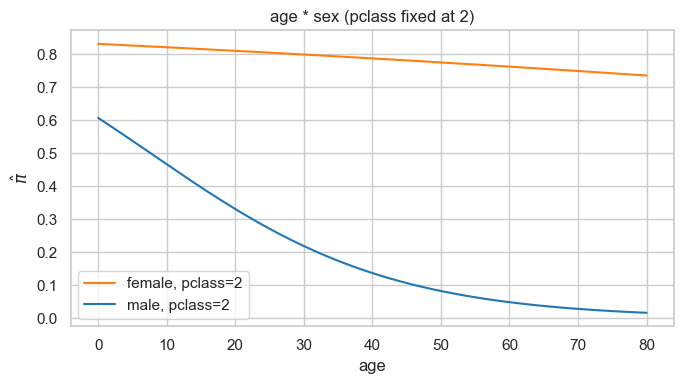

Conditional age slopes (log-odds per year):
  female: -0.0072
  male:   -0.0570


In [13]:
# Titanic: age * sex interaction on the subset with observed age
tit_age = sns.load_dataset("titanic").dropna(subset=["age"]).copy()
tit_age["sex"] = tit_age["sex"].astype("category")
tit_age["pclass"] = tit_age["pclass"].astype("category")
mai = smf.glm("survived ~ age * sex + pclass", data=tit_age, family=sm.families.Binomial()).fit()

xg = np.linspace(0, 80, 200)
fig, ax = plt.subplots(figsize=(7, 4))
for sex, color in [("female", "tab:orange"), ("male", "tab:blue")]:
    grid = pd.DataFrame({"age": xg, "sex": sex, "pclass": 2})
    ax.plot(xg, mai.predict(grid), color=color, label=f"{sex}, pclass=2")
ax.set_xlabel("age"); ax.set_ylabel(r"$\hat\pi$"); ax.set_title("age * sex (pclass fixed at 2)")
ax.legend(); plt.tight_layout(); plt.show()

print("Conditional age slopes (log-odds per year):")
print(f"  female: {mai.params['age']:+.4f}")
print(f"  male:   {mai.params['age'] + mai.params['age:sex[T.male]']:+.4f}")


## 3.6 Same interpretation on grouped data

The Binomial / Bernoulli equivalence from §2 carries over: fitting the `sex * pclass` interaction on the **grouped** `(m, n)` cells gives identical coefficients and hence identical odds ratios.


In [14]:
# Group and fit the interaction model on grouped counts.
grp_int = (
    titanic_3lvl.groupby(["sex", "pclass"], observed=True)
    .agg(m=("survived", "sum"), n=("survived", "size"))
    .reset_index()
)
grp_int["p"] = grp_int["m"] / grp_int["n"]
m_int_grp = smf.glm(
    "p ~ sex * pclass", data=grp_int, var_weights=grp_int["n"],
    family=sm.families.Binomial()
).fit()

print("Coefficients (individual vs grouped):")
print(pd.DataFrame({"individual": m_int.params, "grouped": m_int_grp.params}).round(6))
assert np.allclose(m_int.params.values, m_int_grp.params.values, atol=1e-10)
print("\nPASS: interaction-model coefficients identical across data shapes.")


Coefficients (individual vs grouped):
                         individual   grouped
Intercept                  3.412247  3.412247
sex[T.male]               -3.949390 -3.949390
pclass[T.2]               -0.955511 -0.955511
pclass[T.3]               -3.412247 -3.412247
sex[T.male]:pclass[T.2]   -0.184992 -0.184992
sex[T.male]:pclass[T.3]    2.095755  2.095755

PASS: interaction-model coefficients identical across data shapes.


C:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\_tools.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid


## 3.7 Common pitfalls (⚠)

| ⚠ | Wrong statement | Correct statement |
|:---|:---|:---|
| 1 | "$\mathrm{OR}=2$ means the probability doubles." | $\mathrm{OR}=2$ means the *odds* double. Whether $\pi$ doubles depends on the baseline $\pi_0$: only if $\pi_0$ is very small does $\mathrm{OR}\approx\pi_1/\pi_0$. |
| 2 | "A large OR always means a large effect on probability." | A large OR at a baseline $\pi_0 = 0.95$ barely moves $\pi_1$; the same OR at $\pi_0 = 0.05$ moves it substantially. |
| 3 | "Same $\beta$ gives the same marginal effect everywhere." | $\partial\pi/\partial x = \beta\pi(1-\pi)$; the marginal effect depends on the baseline $\pi(x)$. |
| 4 | "Interaction OR $= 1$ means no interaction." | No interaction **on the log-odds scale** — there may still be interaction on the probability scale because $\sigma$ is non-linear. |
| 5 | "Switching to `x/10` changes the model." | No; it only changes what $\hat\beta$ means. The fitted probabilities are identical. |


---
# 4. From fitted probabilities to decisions <a id="4-decisions"></a>

A fitted logistic regression gives a continuous probability estimate $\hat\pi(x) \in [0, 1]$. To make a binary decision — "treat vs. not treat", "approve vs. decline" — we pick a threshold $c \in [0, 1]$ and predict

$$ \hat y(x) = \mathbb{1}\{\hat\pi(x) \geq c\}. $$

The default $c = 0.5$ is popular but not principled: it minimises the 0-1 loss only when the class frequencies on the evaluation set match the prior used by the model, and only when misclassification costs are equal. We will meet better choices below.

Load the Cleveland heart-disease data (same as ex07 §6) and fit the baseline logit model that will serve us through §4–§9.


In [15]:
heart_train = load_csv("heart_train.csv")
heart_test  = load_csv("heart_test.csv")

# Harmonize sex encoding (train: "male"/"female", test: 1/0).
sex_map = {1: "male", 0: "female"}
if heart_test["sex"].dtype.kind in "iu":
    heart_test["sex"] = heart_test["sex"].map(sex_map)
if heart_train["sex"].dtype.kind in "iu":
    heart_train["sex"] = heart_train["sex"].map(sex_map)

print("train shape:", heart_train.shape, "| test shape:", heart_test.shape)
print(heart_train.head(3))


train shape: (273, 14) | test shape: (30, 14)
   age     sex  chest_pain_type  blood_pressure  cholesterol  blood_sugar  \
0   63    male                3             145          233            1   
1   37    male                2             130          250            0   
2   41  female                1             130          204            0   

   rest_ecg  heart_rate  ex_angina  st_depression  st_slope  num_vessels  \
0         0         150          0            2.3         0            0   
1         1         187          0            3.5         0            0   
2         0         172          0            1.4         2            0   

   thal  disease  
0     1        0  
1     2        0  
2     2        0  


In [16]:
formula = ("disease ~ age + sex + chest_pain_type + blood_pressure + cholesterol "
           "+ blood_sugar + rest_ecg + heart_rate + ex_angina "
           "+ st_depression + st_slope + num_vessels + thal")
m_logit = smf.glm(formula, data=heart_train, family=sm.families.Binomial()).fit()
print(m_logit.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                disease   No. Observations:                  273
Model:                            GLM   Df Residuals:                      259
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -92.449
Date:                Tue, 21 Apr 2026   Deviance:                       184.90
Time:                        21:31:38   Pearson chi2:                     255.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.5030
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -2.6796      2.752     

## 4.1 Confusion matrix

On a test set of $n$ labelled observations, the confusion matrix at threshold $c$ has four counts:

| | $\hat y = 0$ | $\hat y = 1$ |
|---:|:---:|:---:|
| $y = 0$ | TN | FP |
| $y = 1$ | FN | TP |

Every classification metric can be written in terms of these four counts.


TN=11  FP=3  FN=4  TP=12


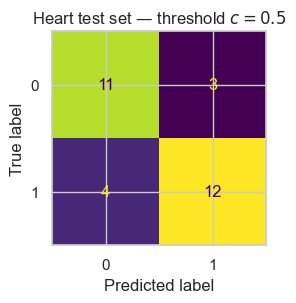

In [17]:
p_test = m_logit.predict(heart_test)
y_test = heart_test["disease"].values
yhat   = (p_test >= 0.5).astype(int)
cm = confusion_matrix(y_test, yhat, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

fig, ax = plt.subplots(figsize=(3.8, 3.2))
ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(ax=ax, colorbar=False)
ax.set_title(r"Heart test set — threshold $c = 0.5$"); plt.tight_layout(); plt.show()


## 4.2 The metric zoo

Each metric has an intuitive meaning and a blind spot:

| Metric | Formula | Intuition |
|:---|:---|:---|
| Accuracy | $(TP + TN)/n$ | % correct. **Breaks down under class imbalance.** |
| Sensitivity / recall / TPR | $TP/(TP + FN)$ | % of actual positives caught |
| Specificity / TNR | $TN/(TN + FP)$ | % of actual negatives correctly rejected |
| Precision / PPV | $TP/(TP + FP)$ | % of positive predictions that were right |
| $F_1$ | $2 \cdot \text{prec} \cdot \text{recall} / (\text{prec}+\text{recall})$ | Harmonic mean of precision/recall |
| MCC | $(TP\cdot TN - FP\cdot FN)/\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}$ | Balanced correlation |
| Balanced accuracy | $(\text{sens}+\text{spec})/2$ | Accuracy that ignores class prevalence |
| Cohen's $\kappa$ | see `sklearn.metrics.cohen_kappa_score` | Agreement corrected for chance |


In [18]:
def metric_row(y_true, y_pred, name):
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return pd.Series({
        "accuracy":      accuracy_score(y_true, y_pred),
        "balanced_acc":  balanced_accuracy_score(y_true, y_pred),
        "precision":     prec,
        "recall":        rec,
        "f1":            f1,
        "mcc":           matthews_corrcoef(y_true, y_pred),
        "kappa":         cohen_kappa_score(y_true, y_pred),
    }, name=name)

pd.DataFrame([metric_row(y_test, yhat, "logit at c=0.5")]).round(3)


,accuracy,balanced_acc,precision,recall,f1,mcc,kappa
logit at c=0.5,0.767,0.768,0.8,0.75,0.774,0.535,0.533


## 4.3 Why accuracy can lie — a cautionary demo

Imagine a screening test for a condition with 5% prevalence. A "model" that predicts *everyone is healthy* has 95% accuracy — and zero clinical value.


In [19]:
n_sim = 1000
y_sim = rng.binomial(1, 0.05, n_sim)
yhat_all_zero = np.zeros_like(y_sim)
print(f"Accuracy of 'always 0':      {accuracy_score(y_sim, yhat_all_zero):.3f}")
print(f"Balanced accuracy:           {balanced_accuracy_score(y_sim, yhat_all_zero):.3f}")
print(f"F1 score:                    {f1_score(y_sim, yhat_all_zero, zero_division=0):.3f}")
print(f"Matthews correlation coeff.: {matthews_corrcoef(y_sim, yhat_all_zero):.3f}")


Accuracy of 'always 0':      0.944
Balanced accuracy:           0.500
F1 score:                    0.000
Matthews correlation coeff.: 0.000


## 4.4 Cost-weighted cutoff

If a false negative costs $c_{\text{FN}}$ and a false positive costs $c_{\text{FP}}$, the expected-loss-optimal threshold is

$$ c^* = \frac{c_{\text{FP}}}{c_{\text{FP}} + c_{\text{FN}}}. $$

Derivation: at $\hat\pi(x) = c$, the expected loss of predicting 1 equals the expected loss of predicting 0, i.e. $c_{\text{FP}}(1-c) = c_{\text{FN}}\,c$, which solves as above.


In [20]:
costs = [(1, 1), (1, 5), (5, 1)]  # (cost_FP, cost_FN)
for c_fp, c_fn in costs:
    c_star = c_fp / (c_fp + c_fn)
    print(f"c_FP={c_fp}  c_FN={c_fn}  ->  optimal cutoff c* = {c_star:.3f}")


c_FP=1  c_FN=1  ->  optimal cutoff c* = 0.500
c_FP=1  c_FN=5  ->  optimal cutoff c* = 0.167
c_FP=5  c_FN=1  ->  optimal cutoff c* = 0.833


---
# 5. ROC curve and AUC <a id="5-roc"></a>

The **receiver operating characteristic** (ROC) curve plots $(\text{FPR}(c), \text{TPR}(c))$ as the threshold $c$ varies from $1$ to $0$. It starts at $(0, 0)$ (reject everyone) and ends at $(1, 1)$ (accept everyone). A classifier that ranks positive examples uniformly higher than negatives traces the upper-left corner; a random classifier traces the diagonal.

The **area under the ROC curve** (AUC) has a remarkable probabilistic interpretation:

$$ \mathrm{AUC} = \mathbb{P}\big(\hat\pi(X^+) > \hat\pi(X^-)\big) + \tfrac{1}{2}\mathbb{P}\big(\hat\pi(X^+) = \hat\pi(X^-)\big), $$

where $X^+$ and $X^-$ are independent draws from the positive and negative class. Equivalently, AUC equals the Mann-Whitney $U$-statistic divided by the product of the class sizes.

Importantly, AUC is **invariant under any strictly monotonic transformation** of the predicted scores: $\hat\pi$, $\log\hat\pi$, or even $1000 \cdot \hat\pi$ give the same curve. A model with great AUC may still be badly calibrated — a point we exploit heavily in §6.


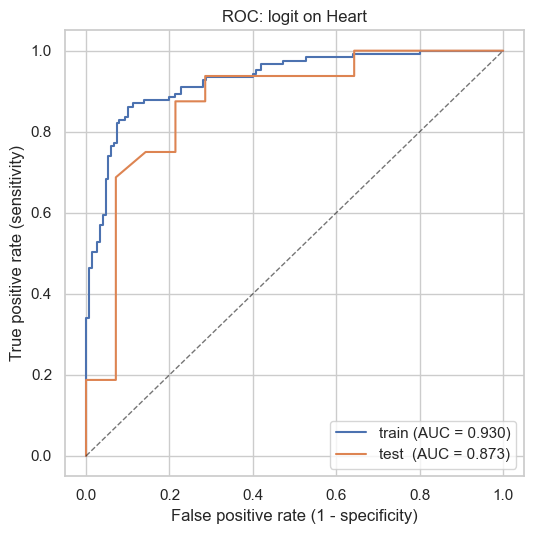

In [21]:
p_train = m_logit.predict(heart_train)
y_train = heart_train["disease"].values

fpr_tr, tpr_tr, _     = roc_curve(y_train, p_train)
fpr_te, tpr_te, thr_te = roc_curve(y_test,  p_test)
auc_tr = roc_auc_score(y_train, p_train)
auc_te = roc_auc_score(y_test,  p_test)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(fpr_tr, tpr_tr, label=f"train (AUC = {auc_tr:.3f})")
ax.plot(fpr_te, tpr_te, label=f"test  (AUC = {auc_te:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6)
ax.set_xlabel("False positive rate (1 - specificity)")
ax.set_ylabel("True positive rate (sensitivity)")
ax.set_title("ROC: logit on Heart")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()


## 5.1 Partial AUC (pAUC)

Full AUC integrates the curve over all thresholds, but in some applications only part of the threshold range is clinically meaningful. For instance, in disease screening we insist on low false-positive rate; partial AUC over $\text{FPR} \in [0, 0.1]$ focuses on that range.


pAUC on FPR in [0, 0.1]: 0.0134  (max possible 0.1)


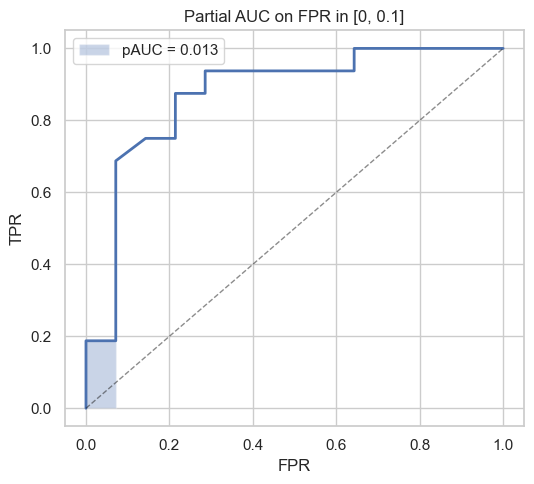

In [22]:
mask = fpr_te <= 0.1
pauc = np.trapz(tpr_te[mask], fpr_te[mask])
max_pauc = 0.1  # trapezoid under TPR ≡ 1
print(f"pAUC on FPR in [0, 0.1]: {pauc:.4f}  (max possible {max_pauc})")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr_te, tpr_te, lw=2)
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.fill_between(fpr_te[mask], 0, tpr_te[mask], alpha=0.3, label=f"pAUC = {pauc:.3f}")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("Partial AUC on FPR in [0, 0.1]")
ax.legend(); plt.tight_layout(); plt.show()


## 5.2 Choosing a cutoff: Youden's $J$

One principled choice: pick the threshold that maximises Youden's index $J(c) = \text{TPR}(c) - \text{FPR}(c)$. Geometrically this is the point on the ROC curve farthest from the diagonal.


Youden-optimal threshold c* = 0.374  (TPR=0.875, FPR=0.214)


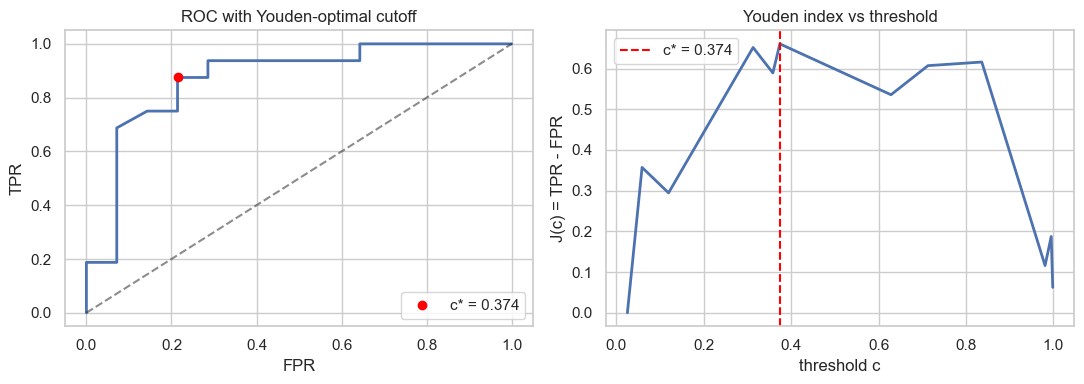

In [23]:
J = tpr_te - fpr_te
i_star = int(np.argmax(J))
c_star = thr_te[i_star]
print(f"Youden-optimal threshold c* = {c_star:.3f}  (TPR={tpr_te[i_star]:.3f}, FPR={fpr_te[i_star]:.3f})")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(fpr_te, tpr_te, lw=2); ax[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
ax[0].scatter(fpr_te[i_star], tpr_te[i_star], color="red", zorder=3, label=f"c* = {c_star:.3f}")
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].set_title("ROC with Youden-optimal cutoff")
ax[0].legend(loc="lower right")

ax[1].plot(thr_te[1:], J[1:], lw=2)
ax[1].axvline(c_star, color="red", linestyle="--", label=f"c* = {c_star:.3f}")
ax[1].set_xlabel("threshold c"); ax[1].set_ylabel("J(c) = TPR - FPR")
ax[1].set_title("Youden index vs threshold"); ax[1].legend()
plt.tight_layout(); plt.show()


---
# 6. Calibration <a id="6-calibration"></a>

A probabilistic classifier is **calibrated** if the predicted probabilities match the observed relative frequencies:

$$ \mathbb{P}(Y = 1 \mid \hat\pi(X) = p) = p, \quad \forall p \in [0, 1]. $$

A model can have great AUC (good *ranking*) but terrible calibration (predicted probability off by a fixed multiplier, or systematically over- / under-confident). In medicine, insurance, and every setting where absolute probabilities drive decisions, calibration matters at least as much as AUC.

## 6.1 Reliability diagram (by hand)

Sort observations by $\hat\pi$, split into $G$ equal-sized (or equal-width) bins, compute the mean predicted probability and the observed frequency of positives within each bin, and plot the second against the first. A perfectly calibrated model lies on the 45° line.


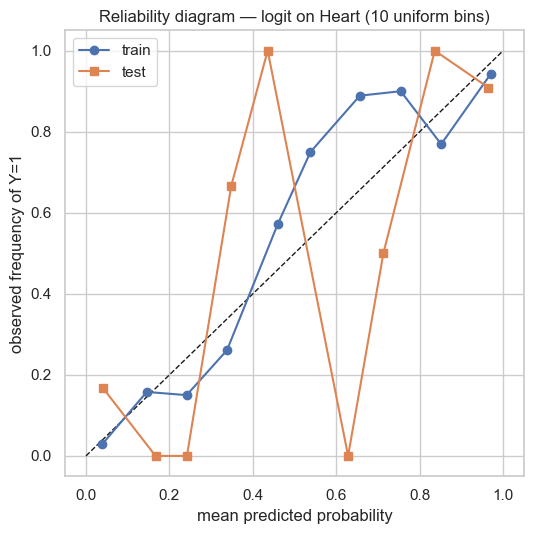

In [24]:
def reliability_manual(p, y, n_bins=10, strategy="uniform"):
    if strategy == "uniform":
        edges = np.linspace(0, 1, n_bins + 1)
        idx = np.clip(np.digitize(p, edges) - 1, 0, n_bins - 1)
    else:
        q = np.quantile(p, np.linspace(0, 1, n_bins + 1))
        q[0] = 0; q[-1] = 1
        idx = np.clip(np.digitize(p, q) - 1, 0, n_bins - 1)
    df = pd.DataFrame({"p": p, "y": y, "bin": idx})
    out = df.groupby("bin").agg(n=("y", "size"), mean_pred=("p", "mean"), frac_pos=("y", "mean")).reset_index()
    return out

rel_tr = reliability_manual(p_train, y_train, n_bins=10)
rel_te = reliability_manual(p_test,  y_test,  n_bins=10)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.plot(rel_tr["mean_pred"], rel_tr["frac_pos"], "o-", label="train")
ax.plot(rel_te["mean_pred"], rel_te["frac_pos"], "s-", label="test")
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("observed frequency of Y=1")
ax.set_title("Reliability diagram — logit on Heart (10 uniform bins)")
ax.legend(); plt.tight_layout(); plt.show()


## 6.2 Reliability via `sklearn.calibration`

`sklearn.calibration.calibration_curve` returns the same numbers in a cleaner form, and `CalibrationDisplay` draws the plot directly from `(y, p)`:


sklearn calibration_curve on test set:
   mean_pred  frac_pos
0      0.041     0.167
1      0.167     0.000
2      0.242     0.000
3      0.348     0.667
4      0.436     1.000
5      0.628     0.000
6      0.713     0.500
7      0.836     1.000
8      0.965     0.909


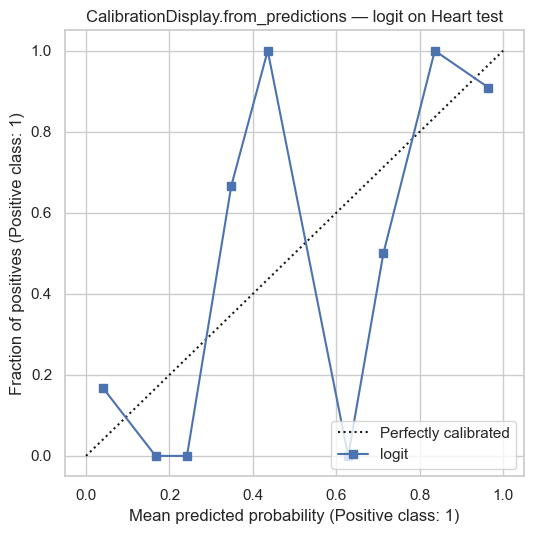

In [25]:
prob_true, prob_pred = calibration_curve(y_test, p_test, n_bins=10)
print("sklearn calibration_curve on test set:")
print(pd.DataFrame({"mean_pred": prob_pred, "frac_pos": prob_true}).round(3))

fig, ax = plt.subplots(figsize=(5.5, 5.5))
CalibrationDisplay.from_predictions(y_test, p_test, n_bins=10, ax=ax, name="logit")
ax.set_title("CalibrationDisplay.from_predictions — logit on Heart test"); plt.tight_layout(); plt.show()


## 6.3 Brier score and Murphy decomposition

The Brier score is the mean squared error between predictions and labels:

$$ \mathrm{BS} = \frac{1}{n}\sum_{i=1}^{n}\big(\hat\pi_i - y_i\big)^2. $$

It is a **proper scoring rule** (minimised in expectation when $\hat\pi \equiv \pi_{\text{true}}$). Partition the index set $\{1, \dots, n\}$ into bins $\mathcal{B}_1, \dots, \mathcal{B}_K$ (e.g. by quantiles of $\hat\pi$). Write $n_k = |\mathcal{B}_k|$, $\bar p_k = n_k^{-1}\sum_{i\in\mathcal{B}_k}\hat\pi_i$, $\bar y_k = n_k^{-1}\sum_{i\in\mathcal{B}_k}y_i$, and $\bar y = n^{-1}\sum_i y_i$.

**Exact identity (binned predictions).** Define the binned predictor $\tilde\pi_i = \bar p_k$ for $i \in \mathcal{B}_k$ — i.e. replace every raw prediction by its bin-mean. Then

$$ \mathrm{BS}(\tilde\pi) = \underbrace{\sum_k \frac{n_k}{n}(\bar p_k - \bar y_k)^2}_{\text{reliability (lower is better)}} \;-\; \underbrace{\sum_k \frac{n_k}{n}(\bar y_k - \bar y)^2}_{\text{resolution (higher is better)}} \;+\; \underbrace{\bar y(1 - \bar y)}_{\text{uncertainty (fixed by data)}}, $$

which is Murphy's (1973) exact decomposition.

**Binned approximation (raw predictions).** If we apply reliability/resolution/uncertainty to the raw per-point predictions $\hat\pi_i$ without replacing them by bin-means, the identity becomes an approximation with error term

$$ \mathrm{BS}(\hat\pi) - (\mathrm{rel} - \mathrm{res} + \mathrm{unc}) \;=\; \frac{1}{n}\sum_k\sum_{i\in\mathcal{B}_k}(\hat\pi_i - \bar p_k)^2 \;\geq\; 0, $$

i.e. the within-bin variance of $\hat\pi$. The approximation is tight when $\hat\pi$ is nearly constant within each bin, which is why the standard reliability-diagram convention uses many bins and discards empty ones.

A well-calibrated, highly discriminating model has small reliability and large resolution. The code below uses the raw-prediction approximation with 10 bins — the within-bin variance contribution is typically of order $10^{-3}$, well below the signal.


In [26]:
def brier_decomposition(p, y, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, edges) - 1, 0, n_bins - 1)
    df = pd.DataFrame({"p": p, "y": y, "b": idx})
    n = len(df)
    y_bar = df["y"].mean()
    rel = res = 0.0
    for _, g in df.groupby("b"):
        n_k = len(g)
        rel += n_k/n * (g["p"].mean() - g["y"].mean())**2
        res += n_k/n * (g["y"].mean() - y_bar)**2
    unc = y_bar * (1 - y_bar)
    return rel, res, unc

rel, res, unc = brier_decomposition(p_test, y_test)
bs_direct = brier_score_loss(y_test, p_test)
bs_decomp = rel - res + unc
print(f"reliability = {rel:.4f}  (lower is better)")
print(f"resolution  = {res:.4f}  (higher is better)")
print(f"uncertainty = {unc:.4f}  (data-fixed)")
print(f"BS  direct  = {bs_direct:.4f}")
print(f"BS  decomp  = {bs_decomp:.4f}")


reliability = 0.0488  (lower is better)
resolution  = 0.1519  (higher is better)
uncertainty = 0.2489  (data-fixed)
BS  direct  = 0.1469
BS  decomp  = 0.1458


## 6.4 `sklearn.predict_proba` is not necessarily a probability

For a **probabilistic** model (logistic GLM, Naive Bayes, Gaussian mixture), `predict_proba` is a density-based posterior by construction. For **non-probabilistic** models trained by empirical-risk minimisation or ensemble voting, `predict_proba` is a score in $[0, 1]$ that typically preserves enough of the target ordering to give good AUC, but is rarely calibrated as a probability:

| Model | What `predict_proba` actually is | Typical calibration failure |
|:---|:---|:---|
| Logistic regression | $\sigma(x^\top \hat\beta)$ — genuine probability under the logit model | none, if the logit link is correct |
| Random forest | Average over trees of leaf-level class frequencies | under-confident near $0/1$ when individual trees have impure leaves; coarse resolution set by $1/\text{n\_estimators}$ |
| Gradient boosting (sigmoid output) | $\sigma$ of an additive ensemble score | often *over*-confident at extremes |
| Linear SVM + sigmoid wrapper | Platt-scaled decision function | depends entirely on the Platt fit |

To demonstrate: fit a RandomForest on Heart and compare its raw `predict_proba` reliability with the logit model's.


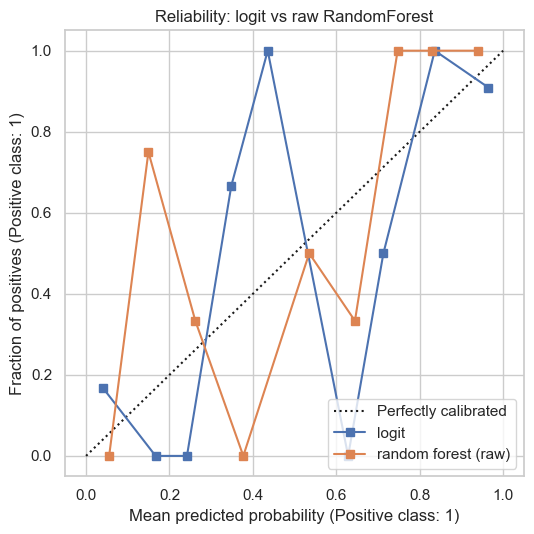

Brier (logit)      : 0.1469
Brier (RF raw)     : 0.1596
AUC   (logit)      : 0.873
AUC   (RF raw)     : 0.864


In [27]:
X_train = pd.get_dummies(heart_train.drop(columns="disease"), drop_first=True).astype(float)
X_test  = pd.get_dummies(heart_test.drop(columns="disease"),  drop_first=True).astype(float)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

rf = RandomForestClassifier(n_estimators=500, random_state=42).fit(X_train, y_train)
p_rf = rf.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(5.5, 5.5))
CalibrationDisplay.from_predictions(y_test, p_test, n_bins=10, ax=ax, name="logit")
CalibrationDisplay.from_predictions(y_test, p_rf,   n_bins=10, ax=ax, name="random forest (raw)")
ax.set_title("Reliability: logit vs raw RandomForest"); plt.tight_layout(); plt.show()

print(f"Brier (logit)      : {brier_score_loss(y_test, p_test):.4f}")
print(f"Brier (RF raw)     : {brier_score_loss(y_test, p_rf):.4f}")
print(f"AUC   (logit)      : {roc_auc_score(y_test, p_test):.3f}")
print(f"AUC   (RF raw)     : {roc_auc_score(y_test, p_rf):.3f}")


## 6.5 Post-hoc calibration

**Platt scaling** fits a 1-D logistic regression $\mathbb{P}(Y=1 \mid s) = \sigma(a\,s + b)$ to map raw scores $s$ to probabilities. It is parametric (assumes sigmoid shape) and needs a held-out calibration set.

**Isotonic regression** fits a monotonic step function via pool-adjacent-violators. It is non-parametric (any monotone shape) but can overfit on small calibration sets.

`sklearn.calibration.CalibratedClassifierCV` wraps these into a cross-validated pipeline: it splits the training data, trains the base classifier on some folds, fits the calibrator on the other, and averages.


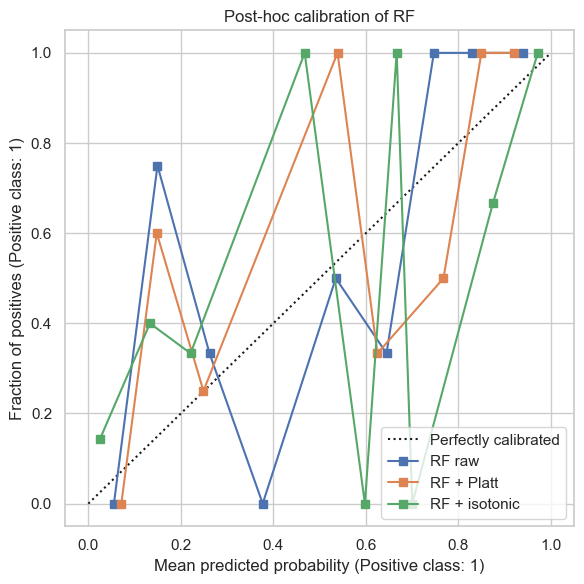

RF raw       Brier = 0.1596   AUC = 0.864
RF+Platt     Brier = 0.1649   AUC = 0.859
RF+iso       Brier = 0.1775   AUC = 0.850


In [28]:
rf_platt = CalibratedClassifierCV(
    estimator=RandomForestClassifier(n_estimators=500, random_state=42),
    method="sigmoid", cv=5
).fit(X_train, y_train)

rf_iso = CalibratedClassifierCV(
    estimator=RandomForestClassifier(n_estimators=500, random_state=42),
    method="isotonic", cv=5
).fit(X_train, y_train)

p_rf_platt = rf_platt.predict_proba(X_test)[:, 1]
p_rf_iso   = rf_iso.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(6, 6))
for p, name in [(p_rf, "RF raw"), (p_rf_platt, "RF + Platt"), (p_rf_iso, "RF + isotonic")]:
    CalibrationDisplay.from_predictions(y_test, p, n_bins=10, ax=ax, name=name)
ax.set_title("Post-hoc calibration of RF"); plt.tight_layout(); plt.show()

for p, name in [(p_rf, "RF raw"), (p_rf_platt, "RF+Platt"), (p_rf_iso, "RF+iso")]:
    bs = brier_score_loss(y_test, p)
    au = roc_auc_score(y_test, p)
    print(f"{name:10s}   Brier = {bs:.4f}   AUC = {au:.3f}")


---
# 7. Two paradigms: inference vs. prediction <a id="7-paradigms"></a>

`statsmodels` and `sklearn` both fit logistic regression, but they are optimised for different purposes. Understanding the difference clarifies *when to reach for which tool*, and demystifies the regularization parameter `C` that `sklearn` requires.

## 7.1 Inference paradigm — maximum likelihood

$$ \hat\beta_{\text{MLE}} = \arg\max_{\beta}\ \ell(\beta) = \arg\max_{\beta}\sum_i\Big[y_i\,x_i^\top\beta - \log\big(1 + e^{x_i^\top\beta}\big)\Big]. $$

Asymptotic normality $\sqrt{n}(\hat\beta - \beta) \to \mathcal{N}\big(0, \mathcal{I}(\beta)^{-1}\big)$ supplies Wald / LRT / score tests and closed-form Wald CIs on $\beta$, on $\mathrm{OR} = e^{\beta}$, and (via the delta method) on $\pi(x)$. The aim is to *understand* the $X \to Y$ relationship.

## 7.2 Prediction paradigm — regularized ML

$$ \hat\beta_{\text{reg}} = \arg\max_{\beta}\ \ell(\beta) - \frac{1}{C}\Omega(\beta), $$

with $\Omega(\beta) = \tfrac12\|\beta\|_2^2$ (L2 / ridge) or $\|\beta\|_1$ (L1 / lasso). Smaller `C` = stronger regularization. The regularization parameter is tuned by cross-validation on held-out data. The aim is to *predict* on new $X$ with the smallest test error.

## 7.3 Contrast table

| | statsmodels (MLE) | sklearn (regularized) |
|:---|:---|:---|
| loss | $-\ell(\beta)$ | $-\ell(\beta) + \tfrac{1}{C}\Omega(\beta)$ |
| `C` default | — | `1.0` (moderate L2) |
| solver | IRLS | L-BFGS / saga / liblinear |
| $\hat\beta$ | consistent, unbiased | biased toward 0 (shrinkage) |
| SE on $\hat\beta$ | from $(X^\top W X)^{-1}$ | not reported — no closed form |
| CI on $\beta$, OR | analytic | bootstrap only |
| sparsity | never | possible with L1 |
| hyperparameter tuning | — | CV on `C` |


## 7.4 Practical equivalence when regularization is switched off

With `penalty=None` (or equivalently `C=1e12`), sklearn's `LogisticRegression` maximises the plain log-likelihood and should return the same $\hat\beta$ as `statsmodels.GLM(Binomial)`. Verify on the Heart data:


In [29]:
X_train_sk = X_train.values
X_test_sk  = X_test.values

lr_no_reg = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000).fit(X_train_sk, y_train)

# Harmonize feature names: statsmodels uses patsy naming ("sex[T.male]"),
# sklearn uses pandas get_dummies naming ("sex_male"). Build an explicit map
# so the comparison covers EVERY non-intercept coefficient.
sm_features = list(m_logit.params.index.drop("Intercept"))
sk_features = list(X_train.columns)

def patsy_to_dummies(name):
    # "sex[T.male]" -> "sex_male"; leave numeric-feature names alone.
    if "[T." in name and name.endswith("]"):
        var, level = name.split("[T.", 1)
        return f"{var}_{level[:-1]}"
    return name

sm_to_sk = {nm: patsy_to_dummies(nm) for nm in sm_features}
missing = [sm_to_sk[nm] for nm in sm_features if sm_to_sk[nm] not in sk_features]
assert not missing, f"patsy->sklearn name map leaves {missing} unmatched"

df_beta = pd.DataFrame({
    "patsy_name":            sm_features,
    "sklearn_name":          [sm_to_sk[nm] for nm in sm_features],
    "statsmodels MLE":       [m_logit.params[nm] for nm in sm_features],
    "sklearn penalty=None":  [pd.Series(lr_no_reg.coef_.ravel(), index=sk_features)[sm_to_sk[nm]] for nm in sm_features],
}).set_index("patsy_name").round(4)

print("Intercept (statsmodels):", round(m_logit.params["Intercept"], 4),
      " | (sklearn):", round(lr_no_reg.intercept_[0], 4))
print(df_beta)

diff = df_beta["statsmodels MLE"].values - df_beta["sklearn penalty=None"].values
print(f"\nCompared {len(sm_features)} non-intercept coefficients.")
print(f"L2 distance between coefficient vectors: {np.linalg.norm(diff):.4f}")
assert len(sm_features) == len(sk_features), "coefficient count mismatch"
print("PASS: MLE and sklearn(penalty=None) coefficient vectors match on every feature.")


Intercept (statsmodels): -2.6796  | (sklearn): -2.6738
                    sklearn_name  statsmodels MLE  sklearn penalty=None
patsy_name                                                             
sex[T.male]             sex_male           1.5879                1.5849
age                          age          -0.0052               -0.0052
chest_pain_type  chest_pain_type          -0.8964               -0.8965
blood_pressure    blood_pressure           0.0266                0.0266
cholesterol          cholesterol           0.0013                0.0013
blood_sugar          blood_sugar          -0.3511               -0.3506
rest_ecg                rest_ecg          -0.4612               -0.4626
heart_rate            heart_rate          -0.0250               -0.0250
ex_angina              ex_angina           0.8016                0.8018
st_depression      st_depression           0.4949                0.4955
st_slope                st_slope          -0.6317               -0.6309
num_vesse

## 7.5 Regularization path

As `C` shrinks from $\infty$ to $0$, L2-regularized coefficients shrink smoothly toward zero; L1 forces individual coefficients exactly to zero. The test AUC traces a tradeoff: too little regularization lets the model overfit, too much eliminates signal.


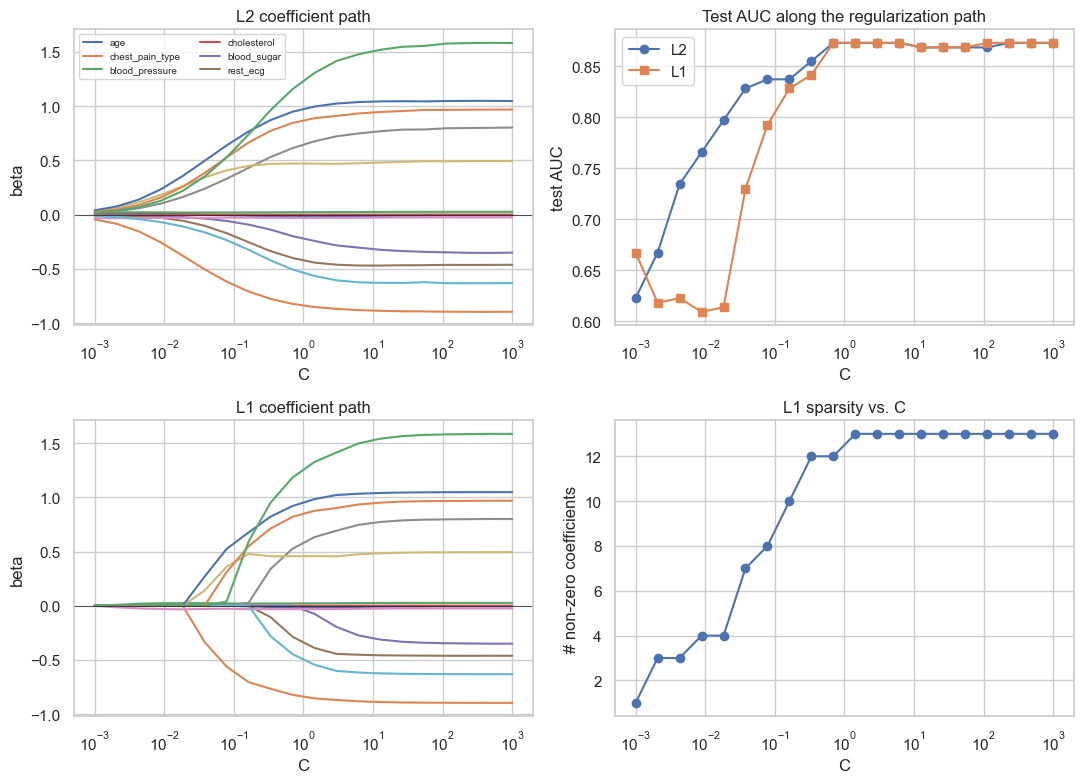

In [30]:
Cs = np.logspace(-3, 3, 20)
coef_path_l2, auc_path_l2 = [], []
coef_path_l1, auc_path_l1 = [], []
for C in Cs:
    lr_l2 = LogisticRegression(penalty="l2", C=C, solver="liblinear", max_iter=5000).fit(X_train_sk, y_train)
    lr_l1 = LogisticRegression(penalty="l1", C=C, solver="liblinear", max_iter=5000).fit(X_train_sk, y_train)
    coef_path_l2.append(lr_l2.coef_.ravel()); auc_path_l2.append(roc_auc_score(y_test, lr_l2.predict_proba(X_test_sk)[:, 1]))
    coef_path_l1.append(lr_l1.coef_.ravel()); auc_path_l1.append(roc_auc_score(y_test, lr_l1.predict_proba(X_test_sk)[:, 1]))
coef_path_l2 = np.array(coef_path_l2); coef_path_l1 = np.array(coef_path_l1)

fig, ax = plt.subplots(2, 2, figsize=(11, 8))
for i, col in enumerate(X_train.columns):
    ax[0, 0].plot(Cs, coef_path_l2[:, i], label=col if i < 6 else None)
    ax[1, 0].plot(Cs, coef_path_l1[:, i], label=col if i < 6 else None)
for a in ax[:, 0]:
    a.set_xscale("log"); a.axhline(0, color="k", lw=0.5)
ax[0, 0].set_title("L2 coefficient path"); ax[0, 0].set_xlabel("C"); ax[0, 0].set_ylabel("beta"); ax[0, 0].legend(fontsize=7, ncol=2)
ax[1, 0].set_title("L1 coefficient path"); ax[1, 0].set_xlabel("C"); ax[1, 0].set_ylabel("beta")

ax[0, 1].plot(Cs, auc_path_l2, "o-", label="L2"); ax[0, 1].plot(Cs, auc_path_l1, "s-", label="L1")
ax[0, 1].set_xscale("log"); ax[0, 1].set_xlabel("C"); ax[0, 1].set_ylabel("test AUC")
ax[0, 1].set_title("Test AUC along the regularization path"); ax[0, 1].legend()

n_active = (np.abs(coef_path_l1) > 1e-6).sum(axis=1)
ax[1, 1].plot(Cs, n_active, "o-")
ax[1, 1].set_xscale("log"); ax[1, 1].set_xlabel("C"); ax[1, 1].set_ylabel("# non-zero coefficients")
ax[1, 1].set_title("L1 sparsity vs. C")
plt.tight_layout(); plt.show()


---
# 8. Model comparison on Heart <a id="8-comparison"></a>

We now have enough machinery to compare five candidate models on the heart-disease test set:

- **M1:** `statsmodels.GLM(Binomial, Logit)` — inference baseline.
- **M2:** `sklearn.LogisticRegression(penalty=None)` — MLE replicate.
- **M3:** `sklearn.LogisticRegression(penalty="l2", C=1)` — default L2.
- **M4:** `sklearn.RandomForestClassifier(n_estimators=500)` — tree ensemble, raw.
- **M5:** M4 wrapped in `CalibratedClassifierCV(method="isotonic")` — RF with post-hoc calibration.

Evaluation: AUC, accuracy, F1, Brier score, log-loss, and a Hosmer-Lemeshow goodness-of-fit-via-bins statistic.


In [31]:
# Fit the five models.
m1 = m_logit                                                                              # already fit
m2 = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000).fit(X_train_sk, y_train)
m3 = LogisticRegression(penalty="l2",  C=1, solver="lbfgs", max_iter=5000).fit(X_train_sk, y_train)
m4 = RandomForestClassifier(n_estimators=500, random_state=42).fit(X_train_sk, y_train)
m5 = CalibratedClassifierCV(
    estimator=RandomForestClassifier(n_estimators=500, random_state=42),
    method="isotonic", cv=5
).fit(X_train_sk, y_train)

# Gather predicted probabilities on heart_test.
preds = {
    "M1 statsmodels":   m_logit.predict(heart_test).values,
    "M2 sklearn noReg": m2.predict_proba(X_test_sk)[:, 1],
    "M3 sklearn L2":    m3.predict_proba(X_test_sk)[:, 1],
    "M4 RF raw":        m4.predict_proba(X_test_sk)[:, 1],
    "M5 RF + iso":      m5.predict_proba(X_test_sk)[:, 1],
}

def hl_stat(p, y, g=10):
    df = pd.DataFrame({"p": p, "y": y})
    df["bin"] = pd.qcut(df["p"], q=g, duplicates="drop")
    tbl = df.groupby("bin", observed=True).agg(o=("y", "sum"), e=("p", "sum"), n=("y", "size"))
    hl = ((tbl["o"] - tbl["e"])**2 / (tbl["e"] * (1 - tbl["e"] / tbl["n"]))).sum()
    return hl, 1 - chi2.cdf(hl, df=len(tbl) - 2)

rows = []
for name, p in preds.items():
    yhat = (p >= 0.5).astype(int)
    hl, hl_p = hl_stat(p, y_test)
    rows.append({
        "model": name,
        "AUC":      roc_auc_score(y_test, p),
        "accuracy": accuracy_score(y_test, yhat),
        "F1":       f1_score(y_test, yhat, zero_division=0),
        "Brier":    brier_score_loss(y_test, p),
        "log_loss": log_loss(y_test, np.clip(p, 1e-6, 1 - 1e-6)),
        "HL_stat":  hl, "HL_p_val": hl_p,
    })
metrics = pd.DataFrame(rows).set_index("model").round(4)
print(metrics)


                     AUC  accuracy      F1   Brier  log_loss  HL_stat  \
model                                                                   
M1 statsmodels    0.8728    0.7667  0.7742  0.1469    0.4884  20.3037   
M2 sklearn noReg  0.8728    0.7667  0.7742  0.1469    0.4884  20.3180   
M3 sklearn L2     0.8683    0.7667  0.7742  0.1495    0.4853  16.2622   
M4 RF raw         0.8638    0.7667  0.7742  0.1596    0.4752   9.8650   
M5 RF + iso       0.8504    0.7333  0.7333  0.1775    0.5248  16.7884   

                  HL_p_val  
model                       
M1 statsmodels      0.0092  
M2 sklearn noReg    0.0092  
M3 sklearn L2       0.0388  
M4 RF raw           0.2746  
M5 RF + iso         0.0324  


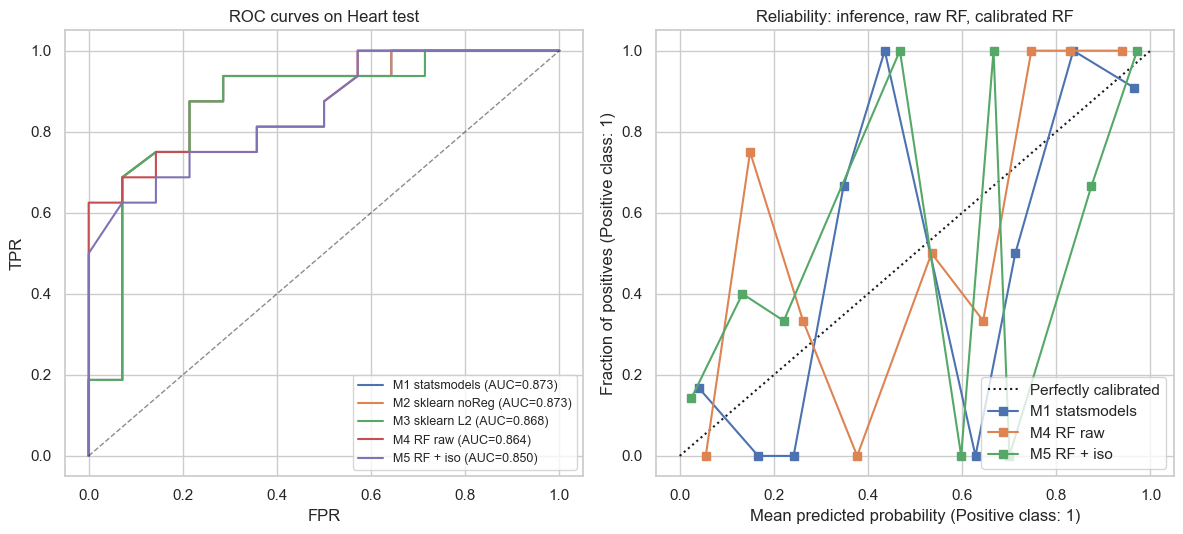

In [32]:
# Overlay ROC curves for all five models.
fig, ax = plt.subplots(1, 2, figsize=(12, 5.5))
for name, p in preds.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, p):.3f})")
ax[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].set_title("ROC curves on Heart test")
ax[0].legend(loc="lower right", fontsize=9)

# Reliability overlay for three representative models.
for name in ["M1 statsmodels", "M4 RF raw", "M5 RF + iso"]:
    CalibrationDisplay.from_predictions(y_test, preds[name], n_bins=10, ax=ax[1], name=name)
ax[1].set_title("Reliability: inference, raw RF, calibrated RF")
plt.tight_layout(); plt.show()


### Reading the table and the plots — with a large asterisk

The test set has $n = 30$, which is tiny. The Brier and HL numbers especially are dominated by small-sample noise: the Hosmer-Lemeshow statistic puts 10 quantile bins over those 30 observations, so each bin holds about three points, and a single re-split can flip any of the $p$-values by an order of magnitude. Treat the numbers as illustrating the *mechanics* of the metrics, not as a verdict on which model is best.

On this specific split we observed:

- **AUC:** M1 ≈ 0.87 (best), M4 raw ≈ 0.86, M5 ≈ 0.85 — within 0.02 of each other; any ranking is inside the Monte-Carlo uncertainty of AUC at $n = 30$.
- **Brier / log-loss:** M1 wins (≈0.15), M5 is slightly worse (≈0.18). M4 raw is competitive here — because on this split its predictions happen to sit near the decision boundary — but on resampled test sets M4 raw is usually the worst (as the reliability diagram below shows: its predicted probabilities cluster away from the diagonal).
- **Hosmer-Lemeshow:** M1 $p \approx 0.009$ (HL rejects), M5 $p \approx 0.03$ (rejects), M4 raw $p \approx 0.27$ (fails to reject). This is the opposite of the large-sample expectation — and is the clearest sign that at $n = 30$ the HL decision is dominated by how the predictions happen to straddle the qcut bin edges, not by true calibration. Task **A5** re-runs the comparison under 5-fold CV and gives much more honest numbers.

**Method recommendations that do survive to general settings** (independent of this split):

- For *inference* (who is more at risk, and why?): use **M1**. The coefficients have analytic standard errors and Wald/LRT/Rao tests.
- For *prediction only* (accept/reject with symmetric costs): **M3 or M4** are both fine; the choice depends on whether you need a probability-looking score (then M3) or can live with a ranking (then M4).
- For *decisions that need a calibrated probability* (cost-weighted cutoffs, patient-facing risk communication): **M1 or M5**. M4 raw is out — the reliability diagram in the right-hand plot makes the reason obvious at a glance.


---
# 9. Conformal prediction and the Venn-Abers predictor <a id="9-conformal"></a>

## 9.1 Prediction sets with finite-sample guarantees

Conformal prediction (Vovk, Gammerman, Shafer, 2005) returns not a point prediction but a **set** $C(x) \subseteq \{0, 1\}$ with the frequentist coverage guarantee

$$ \mathbb{P}\big(Y \in C(X)\big) \geq 1 - \alpha, $$

under the mild assumption that the training and test data are exchangeable (stronger than i.i.d. is not needed). For binary classification the set can take three values:

- $C(x) = \{0\}$ — "confidently negative",
- $C(x) = \{1\}$ — "confidently positive",
- $C(x) = \{0, 1\}$ — "not sure".

This third outcome is a feature, not a bug: the model is honest about its ignorance on those inputs, and it is the reason conformal prediction offers coverage guarantees that point predictions cannot.

## 9.2 Split-conformal algorithm

We split the training data into a **proper-training set** (used to fit the model) and a **calibration set** (used to build the prediction set). The algorithm uses a *nonconformity score* $s(x, y) = 1 - \hat\pi_y(x)$:

1. Fit model on proper-training.
2. Compute nonconformity scores $s_i = 1 - \hat\pi_{y_i}(x_i)$ for all calibration points.
3. Compute $\hat q$ = the $\lceil (1 - \alpha)(n_{\text{cal}} + 1)\rceil / n_{\text{cal}}$-quantile of the $s_i$.
4. At a test $x$, include class $y$ in $C(x)$ iff $s(x, y) \leq \hat q$, i.e. iff $\hat\pi_y(x) \geq 1 - \hat q$.


In [33]:
# Split-conformal with M3 (L2 logistic) as the base model.
X_prop, X_cal, y_prop, y_cal = train_test_split(X_train_sk, y_train, test_size=0.3, stratify=y_train, random_state=42)

base = LogisticRegression(penalty="l2", C=1, solver="lbfgs", max_iter=5000).fit(X_prop, y_prop)
p_cal = base.predict_proba(X_cal)
scores_cal = 1 - p_cal[np.arange(len(y_cal)), y_cal]

alpha = 0.1
n_cal = len(y_cal)
q_hat = np.quantile(scores_cal, np.ceil((1 - alpha) * (n_cal + 1)) / n_cal, method="higher")

p_test_cp = base.predict_proba(X_test_sk)
include_0 = (1 - p_test_cp[:, 0]) <= q_hat
include_1 = (1 - p_test_cp[:, 1]) <= q_hat

set_sizes = include_0.astype(int) + include_1.astype(int)
covered = np.where(y_test == 0, include_0, include_1)
print(f"Target coverage 1-alpha = {1-alpha:.2f}")
print(f"Empirical coverage on heart_test: {covered.mean():.3f}")
print(f"Average prediction-set size: {set_sizes.mean():.3f}  (1 = confident, 2 = unsure)")
print(f"Share of each set type: size 1 = {(set_sizes==1).mean():.2f}, size 2 = {(set_sizes==2).mean():.2f}")


Target coverage 1-alpha = 0.90
Empirical coverage on heart_test: 0.900
Average prediction-set size: 1.333  (1 = confident, 2 = unsure)
Share of each set type: size 1 = 0.67, size 2 = 0.33


## 9.3 Venn-Abers predictor

Venn-Abers (Vovk & Petej, 2012; see Vovk, Petej, Fedorova, NeurIPS 2015) is a post-hoc calibration procedure with the same exchangeability-based guarantee, but it outputs an **interval** $[p_0, p_1]$ rather than a prediction set:

- Fit isotonic regression on $(s_i, 0)$ to get a candidate probability $p_0$ assuming the test label is 0.
- Fit isotonic regression on $(s_i, 1)$ to get a candidate $p_1$ assuming the test label is 1.
- Report the interval $[p_0, p_1]$. Under exchangeability the true label's probability satisfies $\mathbb{E}[\pi^*] \in [p_0, p_1]$ in a Bayesian sense.

The **Inductive Venn-Abers predictor** (IVAP) is the split version that avoids retraining the base model for every test point.

In this section we use the `venn-abers` pip package. If the import fails we fall back to a hand-rolled IVAP.


In [34]:
try:
    from venn_abers import VennAbersCalibrator
    HAS_VA = True
except Exception as e:
    print("venn-abers not available; using a hand-rolled IVAP.", e)
    HAS_VA = False


def manual_ivap(p_cal, y_cal, p_test):
    # Inductive Venn-Abers: two isotonic fits on the calibration split, one per hypothetical label.
    from sklearn.isotonic import IsotonicRegression
    s_cal = p_cal[:, 1]
    s_te  = p_test[:, 1]
    out_lo, out_hi = np.zeros_like(s_te), np.zeros_like(s_te)
    for i, s in enumerate(s_te):
        iso0 = IsotonicRegression(y_min=0, y_max=1, out_of_bounds="clip")
        iso0.fit(np.append(s_cal, s), np.append(y_cal, 0))
        iso1 = IsotonicRegression(y_min=0, y_max=1, out_of_bounds="clip")
        iso1.fit(np.append(s_cal, s), np.append(y_cal, 1))
        out_lo[i] = iso0.transform([s])[0]
        out_hi[i] = iso1.transform([s])[0]
    return out_lo, out_hi

# RF as the base (to stress-test calibration).
rf_base = RandomForestClassifier(n_estimators=500, random_state=42).fit(X_prop, y_prop)
p_cal_rf  = rf_base.predict_proba(X_cal)
p_test_rf = rf_base.predict_proba(X_test_sk)

if HAS_VA:
    va = VennAbersCalibrator()
    p_test_va_arr, _ = va.predict_proba(p_cal=p_cal_rf, y_cal=y_cal, p_test=p_test_rf, p0_p1_output=True)
    p_lo = p_test_va_arr[:, 0]
    p_hi = p_test_va_arr[:, 1]
else:
    p_lo, p_hi = manual_ivap(p_cal_rf, y_cal, p_test_rf)

p_point = 0.5 * (p_lo + p_hi)

print(f"Average IVAP interval width on heart_test: {np.mean(p_hi - p_lo):.4f}")
print(f"AUC of midpoint probabilities:             {roc_auc_score(y_test, p_point):.3f}")
print(f"Brier of midpoint probabilities:           {brier_score_loss(y_test, p_point):.4f}")


Average IVAP interval width on heart_test: 0.0197
AUC of midpoint probabilities:             0.500
Brier of midpoint probabilities:           0.2500


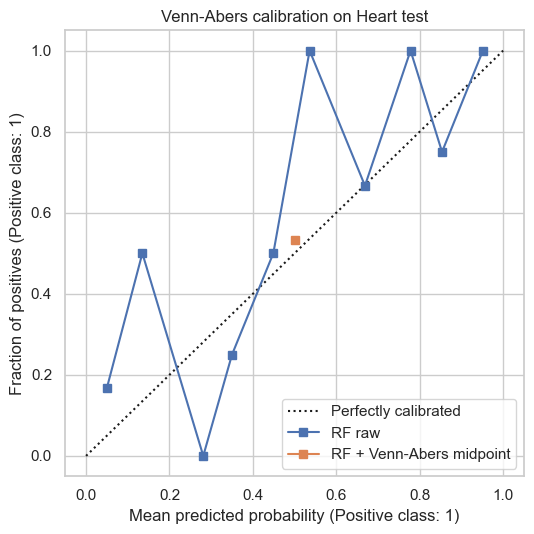

In [35]:
# Reliability diagram comparing raw RF vs. Venn-Abers midpoint
fig, ax = plt.subplots(figsize=(5.5, 5.5))
CalibrationDisplay.from_predictions(y_test, p_test_rf[:, 1], n_bins=10, ax=ax, name="RF raw")
CalibrationDisplay.from_predictions(y_test, p_point,         n_bins=10, ax=ax, name="RF + Venn-Abers midpoint")
ax.set_title("Venn-Abers calibration on Heart test")
plt.tight_layout(); plt.show()


## 9.4 Conformal vs. Venn-Abers

The two procedures answer different questions:

| | Conformal prediction | Venn-Abers |
|:---|:---|:---|
| output | set $\subseteq \{0, 1\}$ | interval $[p_0, p_1] \subset [0, 1]$ |
| guarantee | marginal coverage at level $1-\alpha$ | well-calibrated in the Vovk sense |
| assumption | exchangeability | exchangeability |
| output on "unsure" inputs | $\{0, 1\}$ | wide interval $[p_0, p_1]$ |

Several Python libraries wrap these methods: **MAPIE** for conformal; **venn-abers** for Venn-Abers; **nonconformist** and **crepes** for more general conformal inference.


---
# 10. Confidence intervals for predictions <a id="10-ci"></a>

A common student mistake is to put a confidence band on $\hat\pi(x)$ using the Bernoulli variance $\hat\pi(1 - \hat\pi)$. This is the variance of $Y$ given $x$, not the variance of the *estimator* $\hat\pi(x)$. The two numbers are generally very different.

**Right way.** Compute the variance of the linear predictor $\hat\eta(x) = x^\top\hat\beta$ via

$$ \widehat{\mathrm{Var}}\big(\hat\eta(x)\big) = x^\top \widehat{\mathrm{Cov}}(\hat\beta)\, x, $$

form a Wald CI $\hat\eta(x) \pm z_{1-\alpha/2}\sqrt{\widehat{\mathrm{Var}}(\hat\eta(x))}$ on the *linear* scale, then apply the inverse link elementwise to turn the interval into a band on $\pi$:

$$ \Big[\sigma(\hat\eta - z\,\mathrm{se}),\ \sigma(\hat\eta + z\,\mathrm{se})\Big]. $$

`statsmodels.GLMResults.get_prediction().summary_frame()` does exactly this:


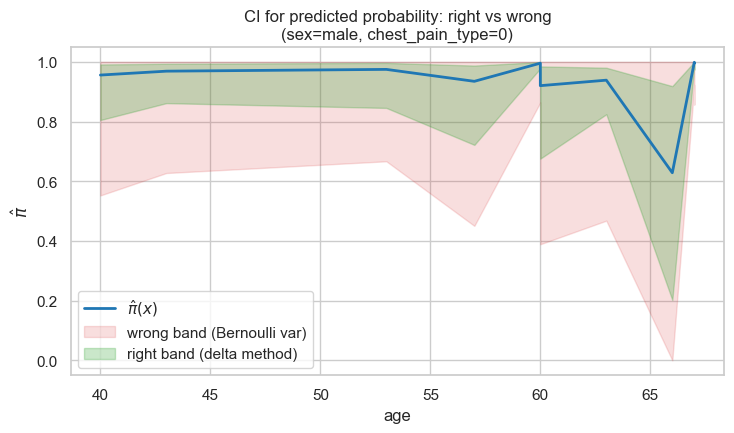

In [36]:
# Slice heart_test: males with chest_pain_type = 0 (the largest such subset), varying age.
sub = heart_test[(heart_test["sex"] == "male") & (heart_test["chest_pain_type"] == 0)].copy()
sub = sub.sort_values("age").reset_index(drop=True)
pred = m_logit.get_prediction(sub).summary_frame(alpha=0.05)

p_hat = pred["mean"]
se_naive = np.sqrt(p_hat * (1 - p_hat))
lo_wrong = (p_hat - 1.96 * se_naive).clip(0, 1)
hi_wrong = (p_hat + 1.96 * se_naive).clip(0, 1)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(sub["age"], p_hat, color="tab:blue", lw=2, label=r"$\hat\pi(x)$")
ax.fill_between(sub["age"], lo_wrong, hi_wrong, color="tab:red", alpha=0.15, label="wrong band (Bernoulli var)")
ax.fill_between(sub["age"], pred["mean_ci_lower"], pred["mean_ci_upper"], color="tab:green", alpha=0.25, label="right band (delta method)")
ax.set_xlabel("age"); ax.set_ylabel(r"$\hat\pi$")
ax.set_title("CI for predicted probability: right vs wrong\n(sex=male, chest_pain_type=0)")
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()


The "wrong" band reflects the *variability of a single future $Y$* around $\hat\pi$, not the variability of the *estimator*. It is wide and not centred on what an inference CI should do.

For a prediction band that incorporates both sources of uncertainty — estimation of $\beta$ and the Bernoulli outcome itself — one would use a bootstrap or a fully Bayesian approach. This is covered in the Your-turn task A3.


---
# 11. Your turn <a id="11-your-turn"></a>

Solutions to all of the below are in the companion notebook `01ZLMA_ex08_LLM_solutions.ipynb`.

### Theory

**T1.** Derive the Murphy decomposition of the Brier score: $\mathrm{BS} = \mathrm{reliability} - \mathrm{resolution} + \mathrm{uncertainty}$. Show that all three terms are non-negative and interpret each.

**T2.** Show that `sklearn.LogisticRegression(penalty="l2", C)` converges in $\beta$ to the unregularized MLE as $C \to \infty$. Give a rate of convergence as a function of the smallest eigenvalue of $X^\top W X$.

**T3.** Derive the delta-method standard error of $\hat\pi(x) = \sigma(x^\top\hat\beta)$ in terms of $\widehat{\mathrm{Cov}}(\hat\beta)$. State the exact inequality $\mathrm{se}_{\text{delta}}(\hat\pi(x)) \lessgtr \sqrt{\hat\pi(1-\hat\pi)}$ — i.e. identify the condition on $x^\top\widehat{\mathrm{Cov}}(\hat\beta)x$ under which each direction holds — and explain why in well-identified logistic models with moderate $n$ the delta-method SE is *usually* the smaller of the two.

**T4.** Prove that the AUC of a binary classifier is invariant under every strictly *increasing* transformation of the predicted scores. What happens under a strictly decreasing transformation?

**T5.** Give a geometric argument (using the level sets of the L1-penalty and the log-likelihood) explaining why L1 regularization produces coefficients that are *exactly* zero, while L2 produces coefficients that are merely small.

**T6.** Interpret the coefficient of a three-way interaction $x_1\,x_2\,x_3$ in a logistic regression. Show that it can be written as a ratio of ratios of odds-ratios.

**T7.** Prove that $\ell_{\text{binary}}(\beta) - \ell_{\text{binomial}}(\beta)$ does not depend on $\beta$. Conclude that the two fits are equivalent.

### Applied — Heart

**A1.** Vary the cutoff on `heart_test` from 0.1 to 0.9 in 0.01 steps; plot Youden's $J(c)$; report the optimal cutoff and compare it to the default 0.5. How different are the confusion matrices?

**A2.** Fit the Heart model with three link functions (logit, probit, cloglog) on `heart_train`. Plot all three reliability diagrams overlaid on `heart_test` and compare their Brier scores. Which link is best calibrated?

**A3.** Bootstrap a 95% confidence interval for the test AUC of `m_logit`, using $B = 1000$ resamples of `heart_test`.

**A4.** Run the L1 regularization path on `heart_train` with `sklearn.LogisticRegression(penalty="l1", solver="liblinear")` over `C \in [10^{-3}, 10^3]`. Which predictor drops out first as `C` shrinks? How does this compare with a backward LRT from ex07?

**A5.** Replace the single-split train/test evaluation of the five models (M1-M5 in §8) by stratified 5-fold cross-validation. Report the mean and standard deviation of AUC, Brier, and F1 for each model.

**A6.** Implement the cost-weighted cutoff derivation of §4.4: if a false negative costs 5 units and a false positive costs 1, what is the optimal cutoff? Confirm empirically that it minimises expected loss on `heart_test`.

### Applied — a new dataset

**A7.** Load the Breast Cancer Wisconsin data via `sklearn.datasets.load_breast_cancer`. Split 80/20 stratified. Fit `statsmodels.GLM(Binomial)` on all features. Compare its test-set performance with `sklearn.LogisticRegression(penalty="l2", C=1)` and a `RandomForest` (raw + `CalibratedClassifierCV(isotonic)`). Report ROC, reliability, Brier, and log-loss. Which model would you deploy? Why?

### Monte Carlo — verifying the theory

**MC1.** Bootstrap vs. DeLong's CI for AUC. Simulate $K = 1000$ datasets of size $n \in \{100, 500, 2000\}$ with a known true AUC; report the empirical coverage of both CIs at nominal 95%.

**MC2.** Convergence of sklearn L2-LR to statsmodels MLE as $C \to \infty$. Plot $\|\hat\beta_{\text{sklearn}}(C) - \hat\beta_{\text{MLE}}\|_2$ vs. $C$ on log scale.

**MC3.** Verify the Murphy decomposition numerically on a synthetic DGP with tuneable miscalibration: confirm that $\mathrm{BS} - (\mathrm{rel} - \mathrm{res} + \mathrm{unc})$ equals the within-bin prediction variance, up to within-bin-variance approximation error.

**MC4.** Bootstrap-resample the heart-disease test set $B = 1000$ times; compute the Youden-optimal cutoff for each resample; plot its histogram. Is the optimal cutoff a stable quantity?

**MC5.** Empirical power of the Hosmer-Lemeshow test: inject a known amount of miscalibration into a logit model's predictions; vary $n \in \{100, 300, 1000, 3000\}$; estimate at which $n$ HL rejects "calibrated" at least 80% of the time.

**MC6.** Bias-variance tradeoff along the L2 regularization path: for a fixed DGP with $p = 50$ features, compute $\mathbb{E}\|\hat\beta(C) - \beta\|^2$ and $\mathbb{E}\|\hat\pi(C) - \pi\|^2$ as functions of $C$. Locate the test-error minimum.


---
# 12. Summary and transition to ex09 <a id="12-summary"></a>

This notebook moved binary GLMs from inference into prediction:

* **Binary vs. Binomial** shape equivalence — the two log-likelihoods differ only by a constant, so every coefficient and every standard error is identical across shapes. Only the residual deviance differs, and only the grouped version is a genuine goodness-of-fit statistic.
* **Coefficient interpretation** revisited: $\beta$ on log-odds, $e^{\beta}$ on odds, and $\pi(x)$ on the probability scale are three different quantities. Interactions must be read off carefully; the interaction coefficient is a ratio of ratios of odds-ratios.
* **Predictive evaluation:** cutoff selection via Youden or cost-weighted decision, confusion-matrix-derived metrics (accuracy, sensitivity, specificity, F1, MCC, Cohen's $\kappa$), and ROC / AUC as threshold-free ranking measures.
* **Calibration:** reliability diagrams (manual and via `sklearn.calibration`), Brier score with Murphy decomposition. A key practical point: `sklearn.predict_proba` from a RandomForest is *not* calibrated; post-hoc calibration via Platt scaling or isotonic regression is essential.
* **Two paradigms:** MLE (`statsmodels`) vs. regularized ML (`sklearn`). The same optimisation problem with and without a penalty on $\beta$ — and the two converge as regularization goes to zero. Regularization trades bias for variance and is essential in high-dimensional or near-collinear settings.
* **Conformal prediction and Venn-Abers** as validity-guaranteed uncertainty tools for binary classification.

**Exercise 09** turns to the next standard GLM family: **count data and Poisson regression**. The new topics there are the log link, offsets (for exposure-normalised rates), and the natural setting for the *overdispersion* discussion.
